# Modelo de Barabasi-Albert

Las redes reales no tienen una cantidad fija de nodos, van creciendo con el tiempo. Cuando un nuevo nodo aparece, se conecta con algunos de los ya existentes. La pregunta es, ¿a cuáles nodos es más probable que se conecte el nuevo nodo?

En el caso no dirigido, al agregar un nuevo nodo, éste se conecta con $m$ de los nodos ya existentes. Por lo que su grado inicial es $m\neq 0$. No es necesario añadir una constante. Así que la probabilidad de que un nodo $i$ sea conectado con el nuevo nodo, es proporcional a su grado $k_i$:

$$\Pi(k_i)=\frac{k_i}{\sum_jk_j}$$

# Actividad

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

SEED = 863
DATA_FP = "data/ca-netscience.mtx"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
def load_collaboration_graph(path):
    # leer aristas
    edges = np.loadtxt(path, comments="%", dtype=int)
    G = nx.Graph()
    G.add_edges_from(edges[:, :2])

    # tomar la componente gigante
    return G.subgraph(max(nx.connected_components(G), key=len)).copy()


def build_hub_mini_network(G, top_k=10, expand_steps=1):
    # elegir hubs
    ranked_hubs = [node for node, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:top_k]]
    backbone = set(ranked_hubs)

    # unir hubs con caminos cortos
    for i, source in enumerate(ranked_hubs):
        for target in ranked_hubs[i + 1:]:
            backbone.update(nx.shortest_path(G, source=source, target=target))

    # crecer una capa mas
    nodes = set(backbone)
    frontier = set(backbone)
    for _ in range(expand_steps):
        frontier = {neighbor for node in frontier for neighbor in G.neighbors(node)} - nodes
        nodes.update(frontier)

    return G.subgraph(nodes).copy(), ranked_hubs, backbone


def degree_distribution(G):
    # contar grados
    degrees = np.array([degree for _, degree in G.degree()])
    values, counts = np.unique(degrees, return_counts=True)
    return values, counts / counts.sum()


def fit_power_law(G):
    # ajuste en log log
    k, pk = degree_distribution(G)
    mask = k > 0
    alpha, log_c = np.polyfit(np.log(k[mask]), np.log(pk[mask]), 1)
    return float(np.exp(log_c)), float(alpha)


def summarize_graph(G, label):
    # resumir metricas
    C, alpha = fit_power_law(G)
    return {
        "red": label,
        "nodos": G.number_of_nodes(),
        "aristas": G.number_of_edges(),
        "grado medio": 2 * G.number_of_edges() / G.number_of_nodes(),
        "densidad": nx.density(G),
        "clustering medio": nx.average_clustering(G),
        "distancia media": nx.average_shortest_path_length(G),
        "C": C,
        "alpha": alpha,
    }


def plot_degree_distribution(ax, G, label, color):
    # datos y ajuste
    k, pk = degree_distribution(G)
    C, alpha = fit_power_law(G)
    x_fit = np.linspace(k[k > 0].min(), k.max(), 200)

    ax.scatter(k, pk, s=40, alpha=0.8, color=color, label=f"{label}: datos")
    ax.plot(x_fit, C * x_fit**alpha, "--", lw=2, color=color, label=f"{label}: ${C:.3f}k^{{{alpha:.2f}}}$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("grado k")
    ax.set_ylabel("P(k)")
    ax.grid(True, which="both", ls=":", alpha=0.4)
    return C, alpha


def prepare_seed_graph(G):
    # renombrar la semilla
    mapping = {node: idx for idx, node in enumerate(G.nodes())}
    reverse_mapping = {idx: node for node, idx in mapping.items()}
    seed_graph = nx.relabel_nodes(G, mapping, copy=True)
    return seed_graph, mapping, reverse_mapping


def draw_graph(ax, G, title, highlight_nodes=None, annotate_nodes=None):
    # resaltar nodos clave
    highlight_nodes = set(highlight_nodes or [])
    annotate_nodes = list(annotate_nodes or [])
    pos = nx.spring_layout(G, seed=SEED, k=0.7 / np.sqrt(G.number_of_nodes()))
    node_colors = ["tab:orange" if node in highlight_nodes else "#7aa6c2" for node in G.nodes()]
    node_sizes = [30 + 8 * G.degree(node) for node in G.nodes()]

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.8, edge_color="#94a3b8")
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        linewidths=0.3,
        edgecolors="white",
    )

    # poner etiquetas
    for node in annotate_nodes:
        ax.text(pos[node][0], pos[node][1], str(node), fontsize=9, ha="center", va="center")

    ax.set_title(title)
    ax.axis("off")
    return pos

# 1

- Considera una subred conexa (de preferencia) que contenga a los nodos con mayor grado. Utiliza la subred como red inicial del modelo de Barabasi_Albert y genera aparte una red con la misma cantidad de nodos que la minired con un valor adecuado de $m$.

Para construir la minired tomé los 10 nodos de mayor grado de la red completa, los conecté con sus caminos más cortos y luego añadí un paso de vecindad. De esta forma la subred queda conexa, conserva a los hubs principales y además mantiene parte de su contexto local.

El valor de $m$ se fija como el entero más cercano a $\bar{k}/2$ de la minired, porque en el modelo de Barabási-Albert el grado medio tiende a ser aproximadamente $2m$.

In [75]:
# cargar la red real
G_real = load_collaboration_graph(DATA_FP)

In [76]:
# construir la minired
mini_real, ranked_hubs, backbone = build_hub_mini_network(G_real, top_k=10, expand_steps=1)

In [77]:
# estimar m
average_degree_mini = np.mean([degree for _, degree in mini_real.degree()])
m = int(round(average_degree_mini / 2))
m = max(1, min(m, mini_real.number_of_nodes() - 1))

In [78]:
# red ba del mismo tamano
G_ba_same = nx.barabasi_albert_graph(mini_real.number_of_nodes(), m, seed=SEED)

In [79]:
# usar la minired como semilla
seed_graph, seed_mapping, reverse_seed_mapping = prepare_seed_graph(mini_real)
G_ba_grown = nx.barabasi_albert_graph(
    G_real.number_of_nodes(),
    m,
    seed=SEED,
    initial_graph=seed_graph,
)

In [80]:
# tabla resumen
summary_df = pd.DataFrame(
    [
        summarize_graph(mini_real, "Minired real"),
        summarize_graph(G_ba_same, "BA mismo tamaño"),
        summarize_graph(G_real, "Red real completa"),
        summarize_graph(G_ba_grown, "BA creciendo desde la minired"),
    ]
).set_index("red").round(3)


In [81]:
# revisar hubs en la minired
hub_presence_df = pd.DataFrame(
    {
        "nodo": ranked_hubs,
        "grado en red real": [G_real.degree(node) for node in ranked_hubs],
        "está en la minired": [node in mini_real for node in ranked_hubs],
    }
)

In [82]:
print(f"m elegido = {m} porque k̄/2 ≈ {average_degree_mini / 2:.2f}")
display(summary_df)

m elegido = 3 porque k̄/2 ≈ 2.55


,nodos,aristas,grado medio,densidad,clustering medio,distancia media,C,alpha
red,,,,,,,,
Minired real,188,479,5.096,0.027,0.805,4.779,0.306,-1.221
BA mismo tamaño,188,555,5.904,0.032,0.071,2.924,1.513,-1.827
Red real completa,379,914,4.823,0.013,0.741,6.042,0.543,-1.553
BA creciendo desde la minired,379,1052,5.551,0.015,0.241,3.495,0.241,-1.274


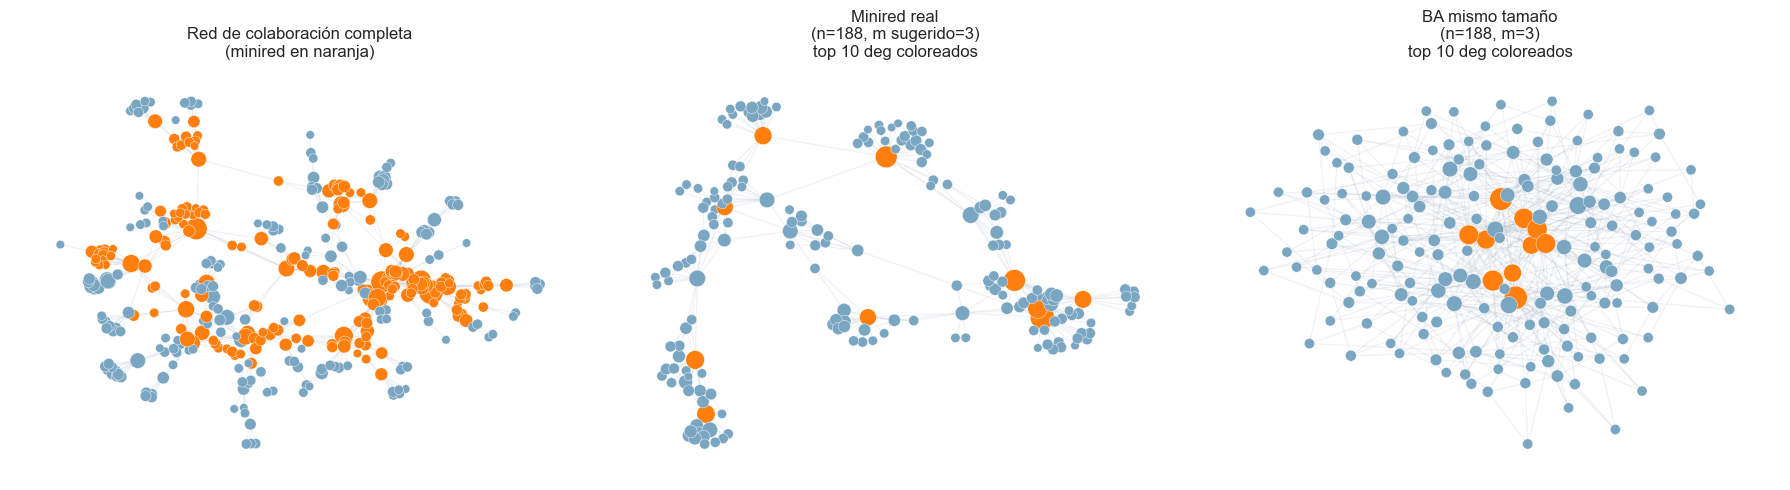

In [83]:
# comparar las tres redes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

draw_graph(
    axes[0],
    G_real,
    "Red de colaboración completa\n(minired en naranja)",
    highlight_nodes=mini_real.nodes(),
)

draw_graph(
    axes[1],
    mini_real,
    f"Minired real\n(n={mini_real.number_of_nodes()}, m sugerido={m})\ntop 10 deg coloreados",
    highlight_nodes=ranked_hubs,
)

# hubs de la red ba
top_ba_same = [node for node, _ in sorted(G_ba_same.degree(), key=lambda x: x[1], reverse=True)[:10]]
draw_graph(
    axes[2],
    G_ba_same,
    f"BA mismo tamaño\n(n={G_ba_same.number_of_nodes()}, m={m})\ntop 10 deg coloreados",
    highlight_nodes=top_ba_same,
)

plt.tight_layout()
plt.show()


# 2

- Grafica la distribución de grados junto con una función $C k^\alpha$ que mejor lo ajuste para ambas redes.

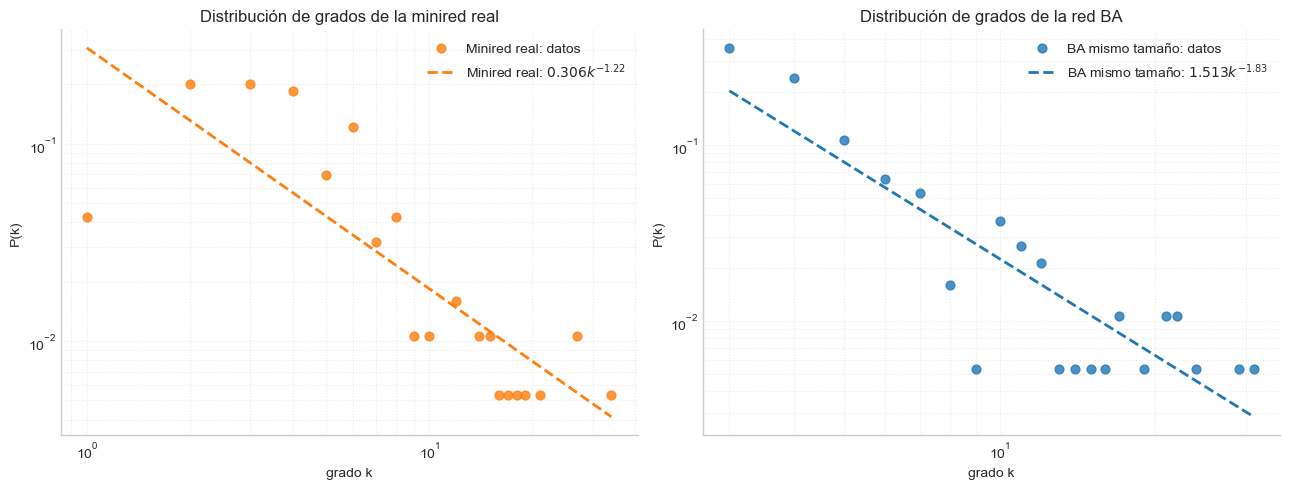

In [97]:
# comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_degree_distribution(axes[0], mini_real, "Minired real", "tab:orange")
axes[0].set_title("Distribución de grados de la minired real")
axes[0].legend()

plot_degree_distribution(axes[1], G_ba_same, "BA mismo tamaño", "tab:blue")
axes[1].set_title("Distribución de grados de la red BA")
axes[1].legend()

plt.tight_layout()
plt.show()

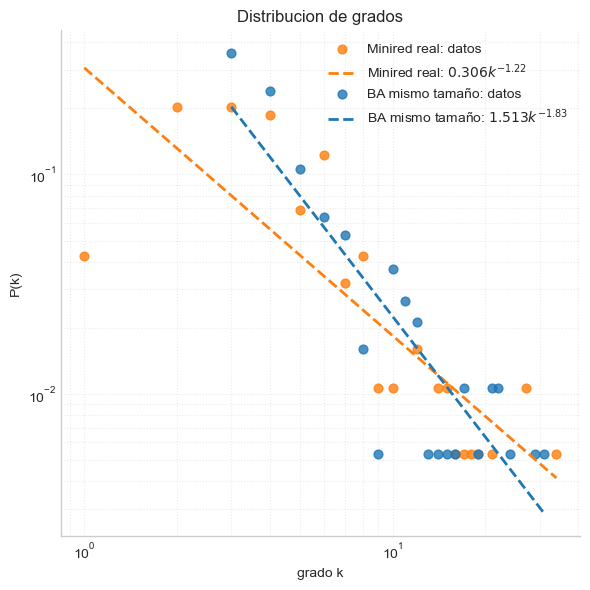

In [101]:
fig, ax = plt.subplots(figsize=(6, 6))

plot_degree_distribution(ax, mini_real, "Minired real", "tab:orange")
plot_degree_distribution(ax, G_ba_same, "BA mismo tamaño", "tab:blue")

ax.set_title("Distribucion de grados")
ax.legend()

plt.tight_layout()
plt.show()


# 3

- ¿Qué diferencia hay entre la red real y la red generada?

La red generada sí produce hubs y una cola pesada en la distribución de grados, pero no reproduce bien la estructura social de colaboración. La minired real tiene mucho más clustering y caminos promedio más largos, lo que sugiere comunidades y bastante cierre triádico; en cambio, la red BA del mismo tamaño tiene menos triadas, concentra enlaces alrededor de hubs pero conecta todo con menos pasos.

In [85]:
# tabla de comparacion local
comparison_same_size = summary_df.loc[["Minired real", "BA mismo tamaño"]]
comparison_same_size

,nodos,aristas,grado medio,densidad,clustering medio,distancia media,C,alpha
red,,,,,,,,
Minired real,188,479,5.096,0.027,0.805,4.779,0.306,-1.221
BA mismo tamaño,188,555,5.904,0.032,0.071,2.924,1.513,-1.827


# 4

- Utiliza la red como red inicial y genera una red con una mayor cantidad de nodos

Tomé como tamaño grande el mismo número de nodos de la red real completa ($n=379$). Así puedo ver qué tanto se parece una red que crece desde la minired a la red de colaboración observada.

,nodos,aristas,grado medio,densidad,clustering medio,distancia media,C,alpha
red,,,,,,,,
Red real completa,379,914,4.823,0.013,0.741,6.042,0.543,-1.553
BA creciendo desde la minired,379,1052,5.551,0.015,0.241,3.495,0.241,-1.274


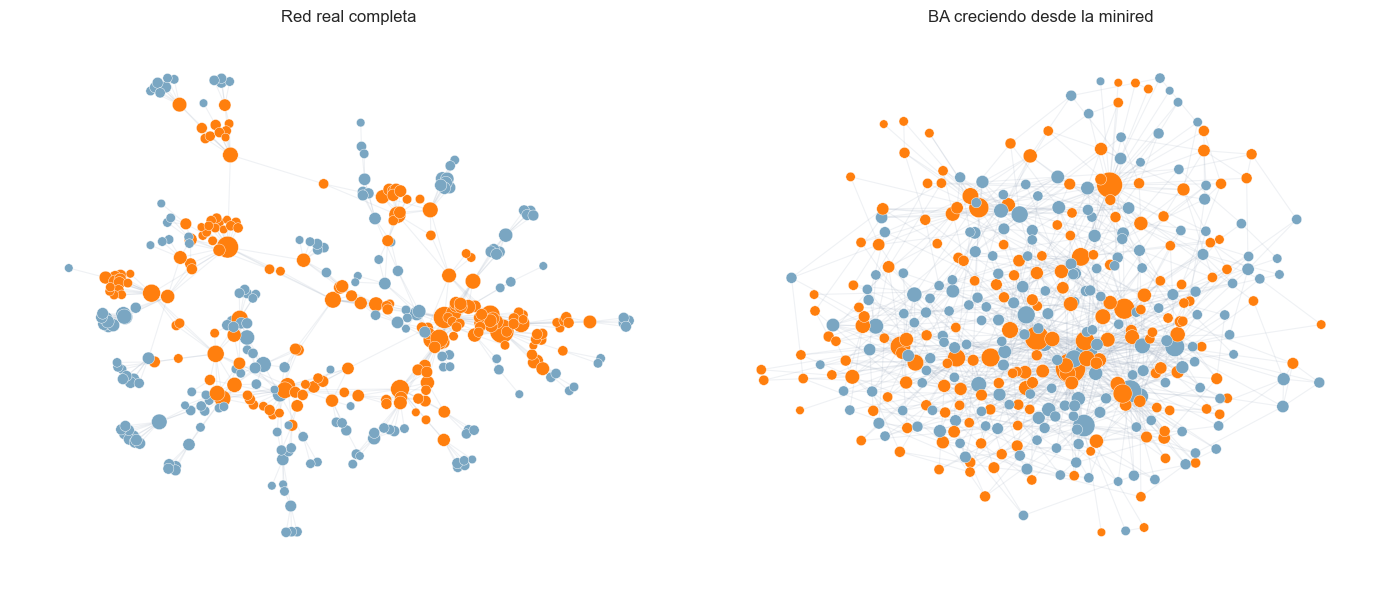

In [104]:
# comparar con la red completa
comparison_full_size = summary_df.loc[["Red real completa", "BA creciendo desde la minired"]]
display(comparison_full_size)

# hubs de la minired
top_mini_nodes = [node for node, _ in sorted(mini_real.degree(), key=lambda x: x[1], reverse=True)[:10]]
top_seed_nodes = [seed_mapping[node] for node in top_mini_nodes]

# red real contra red crecida
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
draw_graph(axes[0], G_real, "Red real completa", highlight_nodes=mini_real.nodes())
draw_graph(
    axes[1],
    G_ba_grown,
    "BA creciendo desde la minired",
    highlight_nodes=mini_real.nodes(),
)
plt.tight_layout()
plt.show()


# 5

- ¿Los nodos de mayor grado de la minired siguen teniendo grado alto en la red generada?

Sí. Los nodos que arrancan como hubs en la minired siguen dominando el ranking final después del crecimiento. Eso es justo lo que uno espera del apego preferencial: tener grado alto al inicio aumenta la probabilidad de recibir más enlaces conforme se agregan nodos nuevos.

In [87]:
# ranking final por grado
grown_degree_ranking = [node for node, _ in sorted(G_ba_grown.degree(), key=lambda x: x[1], reverse=True)]

# seguir los hubs iniciales
hub_retention_df = pd.DataFrame(
    {
        "nodo original": top_mini_nodes,
        "grado en la minired": [mini_real.degree(node) for node in top_mini_nodes],
        "grado en la red crecida": [G_ba_grown.degree(seed_mapping[node]) for node in top_mini_nodes],
        "posición en ranking final": [grown_degree_ranking.index(seed_mapping[node]) + 1 for node in top_mini_nodes],
    }
).sort_values("posición en ranking final")

hub_retention_df

,nodo original,grado en la minired,grado en la red crecida,posición en ranking final
0,4,34,55,1
2,26,27,39,2
1,5,27,34,3
5,70,18,30,4
3,16,21,28,5
4,67,19,28,6
8,51,15,24,7
9,113,15,23,8
6,95,17,22,9
7,15,16,21,10


# 6

- Grafica la distribución de grados junto con una función $C k^\alpha$ que mejor lo ajuste.

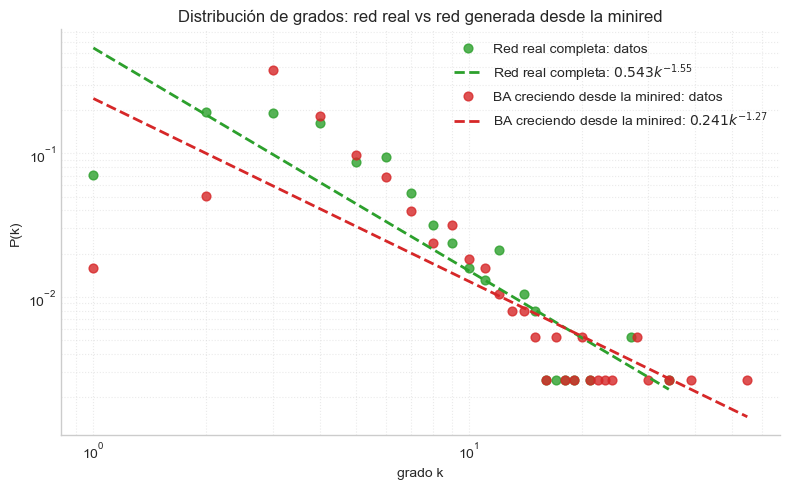

In [105]:
# comparar la cola de grados
fig, ax = plt.subplots(figsize=(8, 5))

plot_degree_distribution(ax, G_real, "Red real completa", "tab:green")
plot_degree_distribution(ax, G_ba_grown, "BA creciendo desde la minired", "tab:red")

ax.set_title("Distribución de grados: red real vs red generada desde la minired")
ax.legend()
plt.tight_layout()
plt.show()

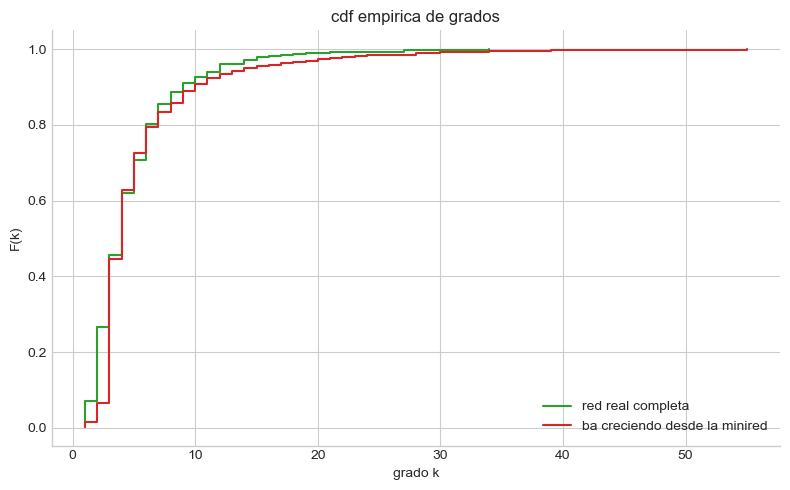

In [108]:
# grados de cada red
deg_real = np.array([d for _, d in G_real.degree()])
deg_ba = np.array([d for _, d in G_ba_grown.degree()])

# cdf empirica
def ecdf(x):
    x = np.sort(np.asarray(x))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x_real, y_real = ecdf(deg_real)
x_ba, y_ba = ecdf(deg_ba)

# graficar cdfs
fig, ax = plt.subplots(figsize=(8, 5))

ax.step(x_real, y_real, where="post", color="tab:green", label="red real completa")
ax.step(x_ba, y_ba, where="post", color="tab:red", label="ba creciendo desde la minired")

ax.set_xlabel("grado k")
ax.set_ylabel("F(k)")
ax.set_title("cdf empirica de grados")
ax.legend()

plt.tight_layout()
plt.show()


La red crecida desde la minired mantiene una distribución de grados con cola pesada y preserva a los hubs semilla, pero todavía no alcanza el clustering alto de la red de colaboración real. La comparación final sugiere que el mecanismo de Barabási-Albert explica bien la aparición y persistencia de hubs, aunque por sí solo no basta para reconstruir la estructura comunitaria típica de una red de colaboración. Como que en la red real hay grupitos (triadas) de colaboradores, y eso no se reproduce en la red crecida.